In [31]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from tqdm import tqdm

In [51]:
def autocorr(traj, taus):
    acf = np.zeros(len(taus))
    start = 500
    x0 = traj[start,:]
    for itau, tau in enumerate(taus):
        xtau = traj[start+tau,:]
        acf[itau] = np.mean((x0-x0.mean())*(xtau-xtau.mean())) / (x0.std()*xtau.std())
    return acf

def cross_corr(traj, taus):
    cross_corr = np.zeros(len(taus))
    start = 500
    x0 = traj[start,:,0]
    for itau, tau in enumerate(taus):
        ytau = traj[start+tau,:,1]
        cross_corr[itau] = np.mean((x0-x0.mean())*(ytau-ytau.mean())) / (x0.std()*ytau.std())
    return cross_corr

#def autocorr2(x): # autocorrelation function
#    r2=np.fft.ifft(np.abs(np.fft.fft(x))**2).real
#    c=(r2/x.shape-np.mean(x)**2)/np.std(x)**2
#    return c[:len(x)//2]

In [58]:
taus = np.arange(0,420,20,dtype=int)
seeds = np.arange(20)

acfsx_p = np.zeros((len(seeds),len(taus)))
acfsx_n = np.zeros((len(seeds),len(taus)))
acfsy_p = np.zeros((len(seeds),len(taus)))
acfsy_n = np.zeros((len(seeds),len(taus)))
cc_p = np.zeros((len(seeds),len(taus)))
cc_n = np.zeros((len(seeds),len(taus)))
for iseed, seed in tqdm(enumerate(seeds)):
    traj = pickle.load(open(
        f"./asymmetric_energy_far/pickles_traj/seed{seed}_N2500_dt0.01_samplingdt1000_nsteps1000000_frict1_temp1.p","rb"
    ))
    acfsx_p[iseed] = autocorr(traj[:,:,0], taus)
    acfsx_n[iseed] = autocorr(traj[:,:,0], -taus)
    acfsy_p[iseed] = autocorr(traj[:,:,1], taus)
    acfsy_n[iseed] = autocorr(traj[:,:,1], -taus)
    cc_p[iseed] = cross_corr(traj, taus)
    cc_n[iseed] = cross_corr(traj, -taus)
#acf2 = autocorr2(traj[100:,100,0])#[taus]

20it [00:02,  8.76it/s]


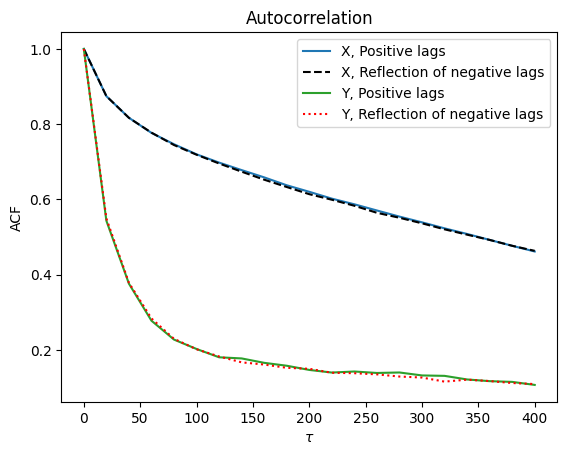

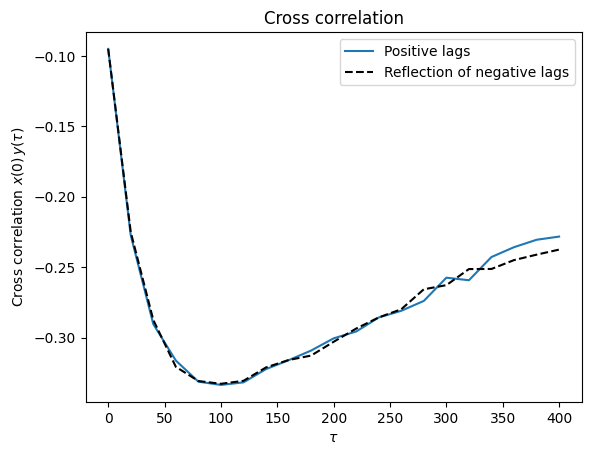

In [65]:
#################################################### PLOT OF ACFS ####################################################
# x variable
mean_acfsx_p = acfsx_p.mean(axis=0)
err_acfsx_p = acfsx_p.std(axis=0) / np.sqrt(acfsx_p.shape[0])
mean_acfsx_n = acfsx_n.mean(axis=0)
err_acfsx_n = acfsx_n.std(axis=0) / np.sqrt(acfsx_n.shape[0])

# y variable
mean_acfsy_p = acfsy_p.mean(axis=0)
err_acfsy_p = acfsy_p.std(axis=0) / np.sqrt(acfsy_p.shape[0])
mean_acfsy_n = acfsy_n.mean(axis=0)
err_acfsy_n = acfsy_n.std(axis=0) / np.sqrt(acfsy_n.shape[0])

plt.plot(taus, mean_acfsx_p, label="X, Positive lags")
#plt.fill_between(taus, mean_acfsx_p - err_acfsx_p, mean_acfsx_p + err_acfsx_p)
plt.plot(taus, mean_acfsx_n, "--", color="black", label="X, Reflection of negative lags")
#plt.fill_between(taus, mean_acfsx_n - err_acfsx_n, mean_acfsx_n + err_acfsx_n)

plt.plot(taus, mean_acfsy_p, color="tab:green", label="Y, Positive lags")
#plt.fill_between(taus, mean_acfsy_p - err_acfsy_p, mean_acfsy_p + err_acfsy_p)
plt.plot(taus, mean_acfsy_n, ":", color="red", label="Y, Reflection of negative lags")
#plt.fill_between(taus, mean_acfsy_n - err_acfsy_n, mean_acfsy_n + err_acfsy_n)

plt.xlabel("Time lag $\\tau$")
plt.ylabel("ACF")
plt.legend()
plt.title("Autocorrelation")
plt.show()

#################################################### PLOT OF CROSS CORRS ####################################################

mean_cc_p = cc_p.mean(axis=0)
err_cc_p = cc_p.std(axis=0) / np.sqrt(acfsx_p.shape[0])
mean_cc_n = cc_n.mean(axis=0)
err_cc_n = cc_n.std(axis=0) / np.sqrt(acfsx_n.shape[0])

plt.plot(taus, mean_cc_p, label="Positive lags")
#plt.fill_between(taus, mean_acfsx_p - err_acfsx_p, mean_acfsx_p + err_acfsx_p)
plt.plot(taus, mean_cc_n, "--", color="black", label="Reflection of negative lags")
#plt.fill_between(taus, mean_acfsx_n - err_acfsx_n, mean_acfsx_n + err_acfsx_n)

plt.xlabel("Time lag $\\tau$")
plt.ylabel("Cross correlation $x(0)\,y(\\tau)$")
plt.legend()
plt.title("Cross correlation")
plt.show()